# Clusterização Hierárquica

## Introdução

Neste notebook, exploraremos os algoritmos de clusterização hierárquica, uma família de métodos que constrói uma hierarquia de clusters organizando os dados em uma estrutura semelhante a uma árvore. Diferentemente do K-Means, que requer que especifiquemos o número de clusters antecipadamente, a clusterização hierárquica nos permite descobrir a estrutura natural dos dados em diferentes níveis de granularidade.

A clusterização hierárquica pode ser dividida em duas abordagens principais:
- **Aglomerativa (Bottom-up)**: Inicia com cada ponto como um cluster individual e, iterativamente, combina os clusters mais próximos até formar um único cluster.
- **Divisiva (Top-down)**: Inicia com todos os pontos em um único cluster e, recursivamente, divide os clusters até que cada ponto forme seu próprio cluster.

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_wine
from scipy.cluster.hierarchy import dendrogram, linkage
import pandas as pd
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## Fundamentação Matemática da Clusterização Hierárquica

A clusterização hierárquica aglomerativa funciona com base em uma **matriz de distâncias** entre todos os pares de pontos (ou clusters). O algoritmo segue estes passos fundamentais:

1. **Inicialização**: Cada observação $\mathbf{x}_i$ forma um cluster individual $C_i = \{\mathbf{x}_i\}$.

2. **Cálculo da Matriz de Distâncias**: Para $N$ pontos, calculamos uma matriz simétrica $D \in \mathbb{R}^{N \times N}$ onde $D_{ij}$ representa a distância entre os pontos $\mathbf{x}_i$ e $\mathbf{x}_j$:
   $$ D_{ij} = d(\mathbf{x}_i, \mathbf{x}_j) $$

3. **Iteração**: Em cada passo, encontramos o par de clusters $(C_i, C_j)$ com menor distância e os combinamos em um novo cluster $C_{ij} = C_i \cup C_j$.

4. **Atualização**: Recalculamos as distâncias do novo cluster para todos os outros clusters existentes.

5. **Terminação**: O processo continua até que reste apenas um cluster contendo todas as observações.

### Critérios de Ligação (Linkage)

O ponto crucial da clusterização hierárquica é como definimos a distância entre dois clusters. Existem vários critérios de ligação:

1. **Single Linkage (Ligação Simples)**:
   $$ d(C_i, C_j) = \min_{\mathbf{x} \in C_i, \mathbf{y} \in C_j} d(\mathbf{x}, \mathbf{y}) $$
   A distância é definida pelos pontos mais próximos entre os clusters.

2. **Complete Linkage (Ligação Completa)**:
   $$ d(C_i, C_j) = \max_{\mathbf{x} \in C_i, \mathbf{y} \in C_j} d(\mathbf{x}, \mathbf{y}) $$
   A distância é definida pelos pontos mais distantes entre os clusters.

3. **Average Linkage (Ligação Média)**:
   $$ d(C_i, C_j) = \frac{1}{|C_i||C_j|} \sum_{\mathbf{x} \in C_i} \sum_{\mathbf{y} \in C_j} d(\mathbf{x}, \mathbf{y}) $$
   A distância é a média de todas as distâncias entre pares de pontos dos clusters.

4. **Ward Linkage (Critério de Ward)**:
   $$d(C_i, C_j) = \frac{|C_i||C_j|}{|C_i|+|C_j|} \|\mathbf{m}_i - \mathbf{m}_j\|^2$$
   Onde $\mathbf{m}_i$ e $\mathbf{m}_j$ são os centróides dos clusters $C_i$ e $C_j$, respectivamente, e $|C_k|$ é o número de pontos no cluster $C_k$.
   Minimiza a variância intra-cluster ao combinar clusters. É baseado na soma dos quadrados das distâncias aos centróides.

## Preparação dos Dados

Vamos começar com um exemplo simples usando dados sintéticos para entender visualmente como funciona a clusterização hierárquica. Depois, aplicaremos o algoritmo ao dataset Iris.

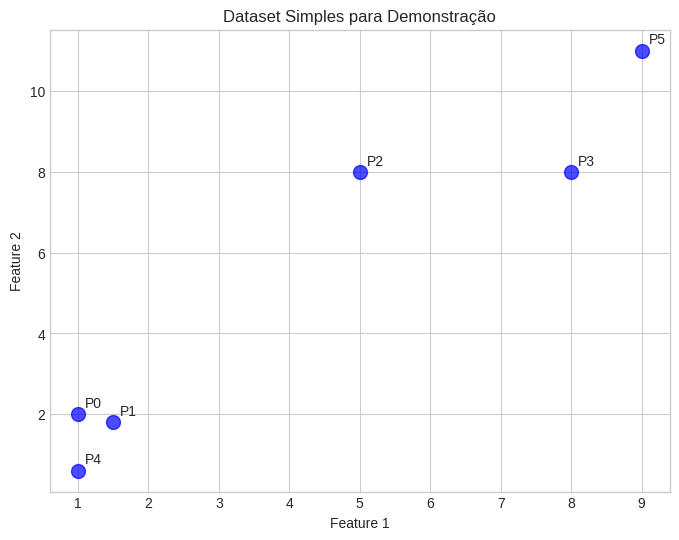

Coordenadas dos pontos:
P0: [1. 2.]
P1: [1.5 1.8]
P2: [5. 8.]
P3: [8. 8.]
P4: [1.  0.6]
P5: [ 9. 11.]


In [24]:
# Gerando dados sintéticos
np.random.seed(42)
X_simple = np.array([[1, 2], [1.5, 1.8], [5, 8], [8, 8], [1, 0.6], [9, 11]])

# Visualizar os dados
plt.figure(figsize=(8, 6))
plt.scatter(X_simple[:, 0], X_simple[:, 1], c='blue', s=100, alpha=0.7)
for i, (x, y) in enumerate(X_simple):
    plt.annotate(f'P{i}', (x, y), xytext=(5, 5), textcoords='offset points')
plt.title('Dataset Simples para Demonstração')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

print(f"Coordenadas dos pontos:")
for i, point in enumerate(X_simple):
    print(f"P{i}: {point}")

## Implementação do Algoritmo Hierárquico Aglomerativo

Vamos construir uma implementação simplificada do algoritmo hierárquico aglomerativo para entender seus passos fundamentais.

In [25]:
from turtle import distance


class HierarchicalClustering:
    def __init__(self, linkage='single'):
        """
        Inicializa o algoritmo de clusterização hierárquica.
        """
        self.linkage = linkage
        self.merge_history = []
        self.distances = []
        
    def _calculate_distance_matrix(self, X):
        """
        Calcula a matriz de distâncias entre todos os pares de pontos.
        """
        n = len(X)
        dist_matrix = np.zeros((n, n))
        for i in range(n):
            for j in range(i+1, n):
                dist = np.linalg.norm(X[i] - X[j])
                dist_matrix[i, j] = dist
                dist_matrix[j, i] = dist

        # Para mais performance, use:
        # diff = X[:, np.newaxis, :] - X[np.newaxis, :, :]
        # dist_matrix = np.linalg.norm(diff, axis=-1)
                
        return dist_matrix
    
    def _cluster_distance(self, cluster1, cluster2, X, dist_matrix):
        """
        Calcula a distância entre dois clusters baseado no critério de ligação.
        """
        if self.linkage == 'single':
            # Distância mínima entre qualquer par de pontos dos clusters
            min_dist = float('inf')
            for i in cluster1:
                for j in cluster2:
                    if dist_matrix[i, j] < min_dist:
                        min_dist = dist_matrix[i, j]
            return min_dist
            
        elif self.linkage == 'complete':
            # Distância máxima entre qualquer par de pontos dos clusters
            max_dist = 0
            for i in cluster1:
                for j in cluster2:
                    if dist_matrix[i, j] > max_dist:
                        max_dist = dist_matrix[i, j]
            return max_dist
            
        
        elif self.linkage == 'avarage':
            soma = 0
            for i in cluster1:
                for j in cluster2:
                    soma += dist_matrix[i,j]
                    
            n_pares = len(cluster1) * len(cluster2)
            media_custers = soma/n_pares 
            return media_custers

        elif self.linkage =='ward':
           
            n_cluster01 = 0
            n_cluster02 = 0
            sum_cluster1 = 0
            sum_cluster2 = 0

            for i in cluster1:
                sum_cluster1 += X[i]
                n_cluster01+=1

            for i in cluster2:
                sum_cluster2+=X[i]
                n_cluster02+=1

            centoroide1 = sum_cluster1/n_cluster01
            centoroide2 = sum_cluster2/n_cluster02


            distancia_in_centroides = np.linalg.norm(centoroide2 - centoroide1)**2
            fator = (n_cluster01*n_cluster02)/(n_cluster01+n_cluster02)
            
            return fator*distancia_in_centroides
        
    def __init__(self, linkage='ward', n_clusters=3):
        self.linkage = linkage
        self.n_clusters = n_clusters

    def fit(self, X):
        """
        Executa o algoritmo de clusterização hierárquica aglomerativa.
        """
        n = len(X)
        
        # Inicializar cada ponto como um cluster
        clusters = [[i] for i in range(n)]
        
        # Calcular matriz de distâncias inicial
        dist_matrix = self._calculate_distance_matrix(X)
        
        self.merge_history = []
        self.distances = []
        
        step = 0
        print(f"Passo inicial: {len(clusters)} clusters individuais")
        print(f"Clusters: {clusters}\n")
        
        # Continuar até que reste apenas um cluster
        while len(clusters) > self.n_clusters:
            # Encontrar o par de clusters mais próximo
            min_distance = float('inf')
            merge_i, merge_j = -1, -1
            
            for i in range(len(clusters)):
                for j in range(i+1, len(clusters)):
                    distance = self._cluster_distance(clusters[i], clusters[j], X, dist_matrix)
                    if distance < min_distance:
                        min_distance = distance
                        merge_i, merge_j = i, j
            
            # Combinar os clusters mais próximos
            new_cluster = clusters[merge_i] + clusters[merge_j]
            
            # Salvar informações da fusão
            self.merge_history.append((clusters[merge_i].copy(), clusters[merge_j].copy()))
            self.distances.append(min_distance)
            
            step += 1
            print(f"Passo {step}: Combinar clusters {clusters[merge_i]} e {clusters[merge_j]}")
            print(f"Distância: {min_distance:.3f}")
            
            # Remover os clusters antigos e adicionar o novo
            clusters = [clusters[k] for k in range(len(clusters)) if k != merge_i and k != merge_j]
            clusters.append(new_cluster)
        self.clusters = clusters
        print(f"Clusters restantes: {clusters}\n")

## Executando o Algoritmo no Dataset Simples

Vamos aplicar nossa implementação nos dados simples para observar passo a passo como os clusters são formados.

In [26]:
# Executar a clusterização hierárquica com ligação simples
hc_single = HierarchicalClustering(linkage='single')
hc_single.fit(X_simple)

Passo inicial: 6 clusters individuais
Clusters: [[0], [1], [2], [3], [4], [5]]

Passo 1: Combinar clusters [0] e [1]
Distância: 0.539
Passo 2: Combinar clusters [4] e [0, 1]
Distância: 1.300
Passo 3: Combinar clusters [2] e [3]
Distância: 3.000
Clusters restantes: [[5], [4, 0, 1], [2, 3]]



## Dendrogramas: Visualizando a Hierarquia

Um **dendrograma** é a representação gráfica da hierarquia de clusters. É uma estrutura em forma de árvore que mostra a ordem e as distâncias nas quais os clusters foram combinados.

### Interpretação do Dendrograma:
- **Eixo horizontal**: Representa as observações ou clusters.
- **Eixo vertical**: Representa a distância na qual os clusters foram unidos.
- **Altura dos ramos**: Indica a dissimilaridade entre os clusters combinados.

Vamos usar a implementação otimizada do SciPy para criar dendrogramas profissionais:

### SciPy: Clusterização Hierárquica

#### `linkage(X, method)`
Calcula a hierarquia de clusters.

```python
from scipy.cluster.hierarchy import linkage
Z = linkage(X, method='ward')
````

* `X`: dados (n_samples × n_features)
* `method`: 'single', 'complete', 'average', 'ward'
* `metric`: distância (default: euclidean)

Retorna uma matriz (n-1) × 4:

* [0,1]: clusters combinados
* [2]: distância da fusão
* [3]: tamanho do cluster

#### `fcluster(Z, t, criterion)`

Extrai clusters da hierarquia.

```python
from scipy.cluster.hierarchy import fcluster

labels = fcluster(Z, t=3.0, criterion='distance')
labels = fcluster(Z, t=3, criterion='maxclust')
```

* `Z`: saída do linkage
* `t`: threshold
* `criterion`: tipo de corte

Critérios:

* `distance`: corta por altura
* `maxclust`: define número de clusters

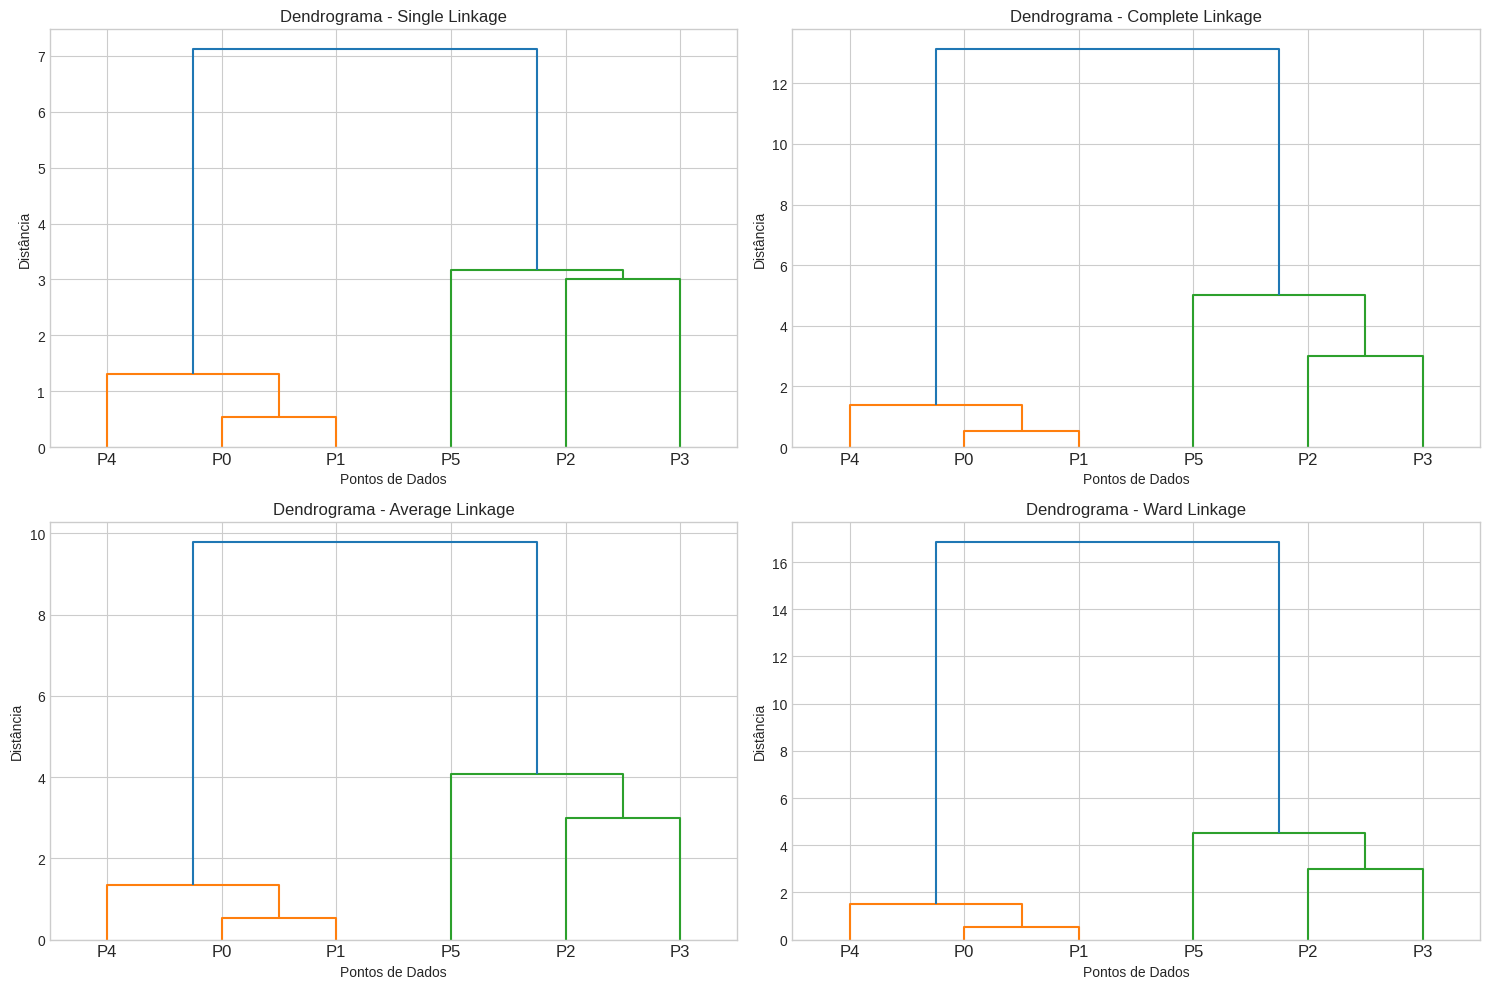

In [27]:
linkage_methods = ['single', 'complete', 'average', 'ward']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for i, method in enumerate(linkage_methods):
    # Calcular a matriz de ligação
    linkage_matrix = linkage(X_simple, method=method)
    
    # Criar o dendrograma
    dendrogram(linkage_matrix, ax=axes[i], labels=[f'P{j}' for j in range(len(X_simple))])
    axes[i].set_title(f'Dendrograma - {method.capitalize()} Linkage')
    axes[i].set_xlabel('Pontos de Dados')
    axes[i].set_ylabel('Distância')

plt.tight_layout()
plt.show()

### Comparação dos Critérios de Ligação

Cada critério de ligação produz diferentes estruturas de cluster:

- **Single Linkage**: Tende a criar clusters elongados e pode sofrer do "efeito corrente" (chaining effect).
- **Complete Linkage**: Produz clusters mais compactos e esféricos.
- **Average Linkage**: Um meio-termo entre single e complete.
- **Ward Linkage**: Minimiza a variância intra-cluster, similar ao objetivo do K-Means.

## Determinando o Número de Clusters

Uma das grandes vantagens da clusterização hierárquica é que podemos "cortar" o dendrograma em diferentes alturas para obter diferentes números de clusters. Isso é feito traçando uma linha horizontal através do dendrograma.

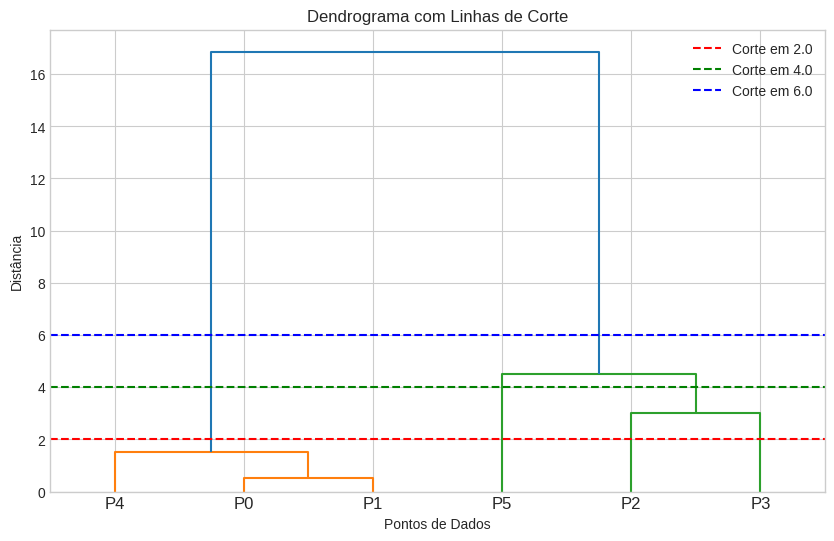

In [28]:
# Usar Ward linkage para o exemplo
linkage_matrix = linkage(X_simple, method='ward')

# Definir diferentes alturas de corte
cut_heights = [2.0, 4.0, 6.0]
colors = ['red', 'green', 'blue']

# Visualizar o dendrograma com diferentes cortes
plt.figure(figsize=(10, 6))
dendrogram(linkage_matrix, labels=[f'P{j}' for j in range(len(X_simple))])

for height, color in zip(cut_heights, colors):
    plt.axhline(y=height, color=color, linestyle='--', label=f'Corte em {height}')

plt.title('Dendrograma com Linhas de Corte')
plt.xlabel('Pontos de Dados')
plt.ylabel('Distância')
plt.legend()
plt.show()

In [29]:
# Predição de clusters baseada em diferentes linhas de corte
from scipy.cluster.hierarchy import fcluster

print("Predição de clusters para diferentes alturas de corte:")
print("=" * 55)

for i, height in enumerate(cut_heights):
    # Obter clusters para a altura de corte específica
    clusters = fcluster(linkage_matrix, height, criterion='distance')
    n_clusters = len(np.unique(clusters))
    
    print()
    print(f"Altura de corte: {height}")
    print(f"Número de clusters: {n_clusters}")
    
    # Mostrar quais pontos pertencem a cada cluster
    for cluster_id in np.unique(clusters):
        points = [f"P{j}" for j in range(len(X_simple)) if clusters[j] == cluster_id]
        print(f"  Cluster {cluster_id}: {points}")

Predição de clusters para diferentes alturas de corte:

Altura de corte: 2.0
Número de clusters: 4
  Cluster 1: ['P0', 'P1', 'P4']
  Cluster 2: ['P2']
  Cluster 3: ['P3']
  Cluster 4: ['P5']

Altura de corte: 4.0
Número de clusters: 3
  Cluster 1: ['P0', 'P1', 'P4']
  Cluster 2: ['P2', 'P3']
  Cluster 3: ['P5']

Altura de corte: 6.0
Número de clusters: 2
  Cluster 1: ['P0', 'P1', 'P4']
  Cluster 2: ['P2', 'P3', 'P5']


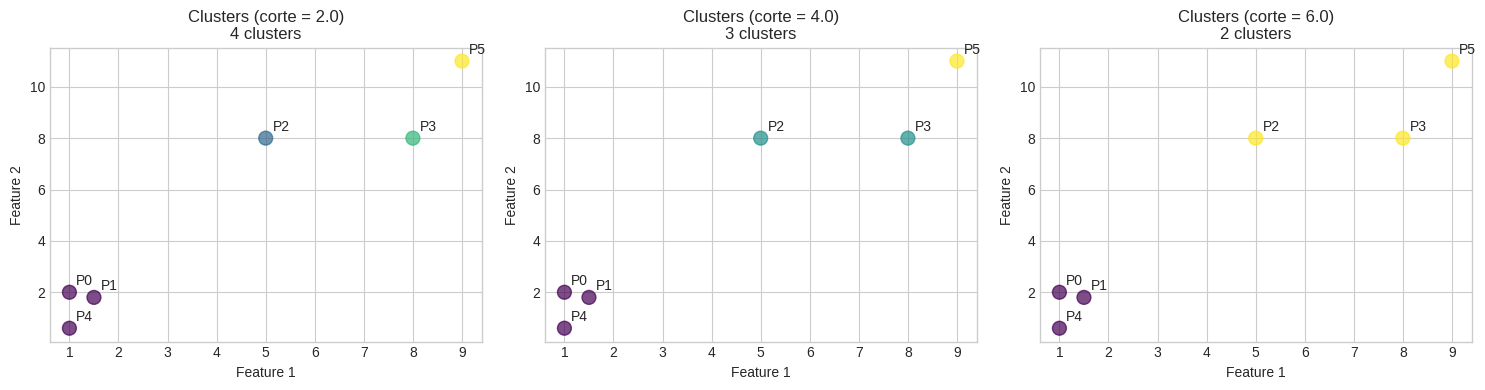

In [30]:
# Visualização dos clusters resultanteslabel
fig, axes = plt.subplots(1, len(cut_heights), figsize=(15, 4))

for i, height in enumerate(cut_heights):
    clusters = fcluster(linkage_matrix, height, criterion='distance')
    scatter = axes[i].scatter(X_simple[:, 0], X_simple[:, 1], c=clusters, s=100, alpha=0.7, cmap='viridis')
    
    # Adicionar rótulos dos pontos
    for j, (x, y) in enumerate(X_simple):
        axes[i].annotate(f'P{j}', (x, y), xytext=(5, 5), textcoords='offset points')
    
    axes[i].set_title(f'Clusters (corte = {height})\n{len(np.unique(clusters))} clusters')
    axes[i].set_xlabel('Feature 1')
    axes[i].set_ylabel('Feature 2')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

## Aplicação ao Dataset Iris

Agora vamos aplicar a clusterização hierárquica ao dataset Iris e comparar os resultados com o K-Means.

NameError: name 'labelX_iris' is not defined

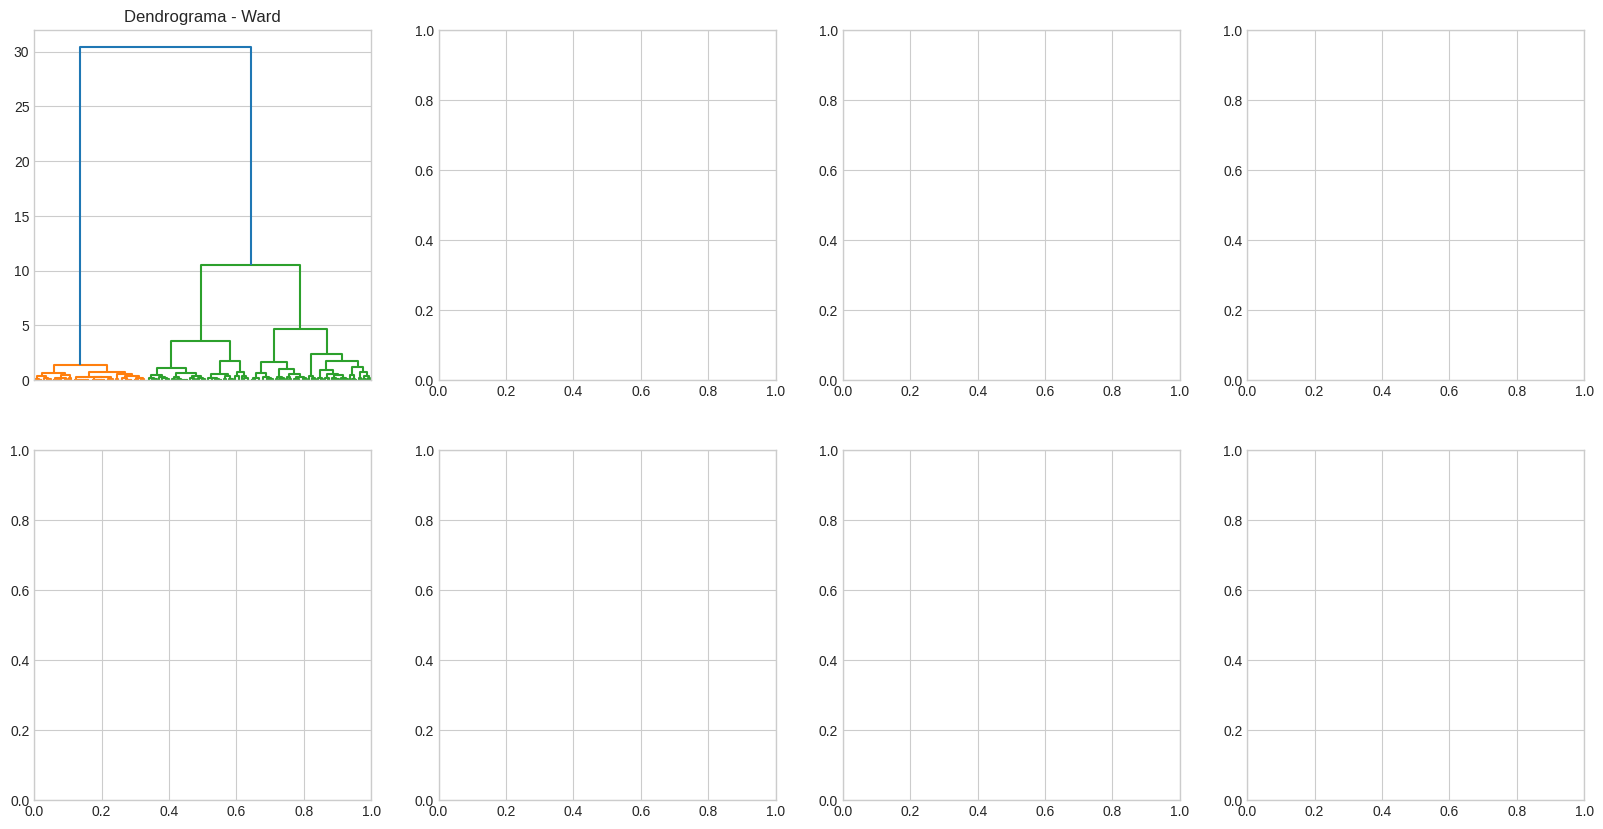

In [31]:
# Carregar o dataset Iris
iris = load_iris()
X_iris = iris.data[:, 2:]  # Usar comprimento e largura da pétala
y_true = iris.target

# Aplicar diferentes métodos de ligação
methods = ['ward', 'complete', 'average', 'single']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, method in enumerate(methods):
    # Calcular a matriz de ligação
    linkage_matrix = linkage(X_iris, method=method)
    
    # Dendrograma
    dendrogram(linkage_matrix, ax=axes[0, i], no_labels=True)
    axes[0, i].set_title(f'Dendrograma - {method.capitalize()}')
    
    # Obter 3 clusters
    clusters = fcluster(linkage_matrix, 3, criterion='maxclust')
    
    # Plotar os clusters
    scatter = axes[1, i].scatter(X_iris[:, 0], labelX_iris[:, 1], c=clusters, s=50, alpha=0.7, cmap='viridis')
    axes[1, i].set_title(f'Clusters - {method.capitalize()}')
    axes[1, i].set_xlabel('Comprimento da Pétala')
    axes[1, i].set_ylabel('Largura da Pétala')
    
plt.tight_layout()
plt.show()

### Avaliação dos Resultados

Vamos calcular a taxa de acertos para cada método de ligação:

In [32]:
from scipy.stats import mode

def calculate_purity(y_true, y_pred):
    """
    Calcula a pureza dos clusters comparando com os rótulos verdadeiros.
    """
    correct_predictions = 0
    n_samples = len(y_true)
    
    for cluster_id in np.unique(y_pred):
        mask = (y_pred == cluster_id)
        if np.sum(mask) > 0:
            dominant_label = mode(y_true[mask], keepdims=True)[0][0]
            correct_predictions += np.sum(y_true[mask] == dominant_label)
    
    return correct_predictions / n_samples

print("Comparação dos métodos de ligação no dataset Iris:")
print("="*50)

for method in methods:
    linkage_matrix = linkage(X_iris, method=method)
    clusters = fcluster(linkage_matrix, 3, criterion='maxclust')
    purity = calculate_purity(y_true, clusters)
    print(f"{method.capitalize():12} Linkage: {purity:.1%} de acertos")

Comparação dos métodos de ligação no dataset Iris:
Ward         Linkage: 96.0% de acertos
Complete     Linkage: 96.0% de acertos
Average      Linkage: 96.0% de acertos
Single       Linkage: 67.3% de acertos


### Exercício 1: Implementação do Average Linkage

Complete a implementação da nossa classe `HierarchicalClustering` adicionando o método **Average Linkage**. Em seguida, teste todos os três métodos de ligação (single, complete, average) no dataset simples (`X_simple`) e compare os resultados.

In [33]:
# Seu código aqui

from sklearn.discriminant_analysis import StandardScaler


data = load_wine()

X =data.data[:15]
scale = StandardScaler()
x_norm= scale.fit_transform(X=X)
print("ward")
hc = HierarchicalClustering(linkage="ward")
hc.fit(x_norm)




ward
Passo inicial: 15 clusters individuais
Clusters: [[0], [1], [2], [3], [4], [5], [6], [7], [8], [9], [10], [11], [12], [13], [14]]

Passo 1: Combinar clusters [11] e [12]
Distância: 2.279
Passo 2: Combinar clusters [6] e [7]
Distância: 5.431
Passo 3: Combinar clusters [5] e [14]
Distância: 5.463
Passo 4: Combinar clusters [8] e [11, 12]
Distância: 6.563
Passo 5: Combinar clusters [0] e [6, 7]
Distância: 7.082
Passo 6: Combinar clusters [10] e [5, 14]
Distância: 8.203
Passo 7: Combinar clusters [1] e [9]
Distância: 9.385
Passo 8: Combinar clusters [2] e [4]
Distância: 9.961
Passo 9: Combinar clusters [8, 11, 12] e [1, 9]
Distância: 11.644
Passo 10: Combinar clusters [3] e [10, 5, 14]
Distância: 13.197
Passo 11: Combinar clusters [0, 6, 7] e [8, 11, 12, 1, 9]
Distância: 18.396
Passo 12: Combinar clusters [13] e [3, 10, 5, 14]
Distância: 19.430
Clusters restantes: [[2, 4], [0, 6, 7, 8, 11, 12, 1, 9], [13, 3, 10, 5, 14]]



In [34]:
print("avarage")
hc = HierarchicalClustering(linkage="avarage")
hc.fit(x_norm)

avarage
Passo inicial: 15 clusters individuais
Clusters: [[0], [1], [2], [3], [4], [5], [6], [7], [8], [9], [10], [11], [12], [13], [14]]

Passo 1: Combinar clusters [11] e [12]
Distância: 2.135
Passo 2: Combinar clusters [6] e [11, 12]
Distância: 3.199
Passo 3: Combinar clusters [5] e [14]
Distância: 3.305
Passo 4: Combinar clusters [8] e [6, 11, 12]
Distância: 3.347
Passo 5: Combinar clusters [0] e [7]
Distância: 3.614
Passo 6: Combinar clusters [10] e [5, 14]
Distância: 3.877
Passo 7: Combinar clusters [1] e [8, 6, 11, 12]
Distância: 4.077
Passo 8: Combinar clusters [9] e [1, 8, 6, 11, 12]
Distância: 4.189
Passo 9: Combinar clusters [2] e [4]
Distância: 4.463
Passo 10: Combinar clusters [0, 7] e [9, 1, 8, 6, 11, 12]
Distância: 4.607
Passo 11: Combinar clusters [3] e [10, 5, 14]
Distância: 4.661
Passo 12: Combinar clusters [0, 7, 9, 1, 8, 6, 11, 12] e [3, 10, 5, 14]
Distância: 5.206
Clusters restantes: [[13], [2, 4], [0, 7, 9, 1, 8, 6, 11, 12, 3, 10, 5, 14]]



### Exercício 2: Análise do Dataset Wine

Aplique a clusterização hierárquica do SciPy ao dataset Wine. Primeiro, você deve selecionar um bom par de features para visualização bidimensional, depois comparar diferentes métodos de ligação.

Dataset Wine:
Shape: (178, 13)
Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Classes: ['class_0' 'class_1' 'class_2']
.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ==

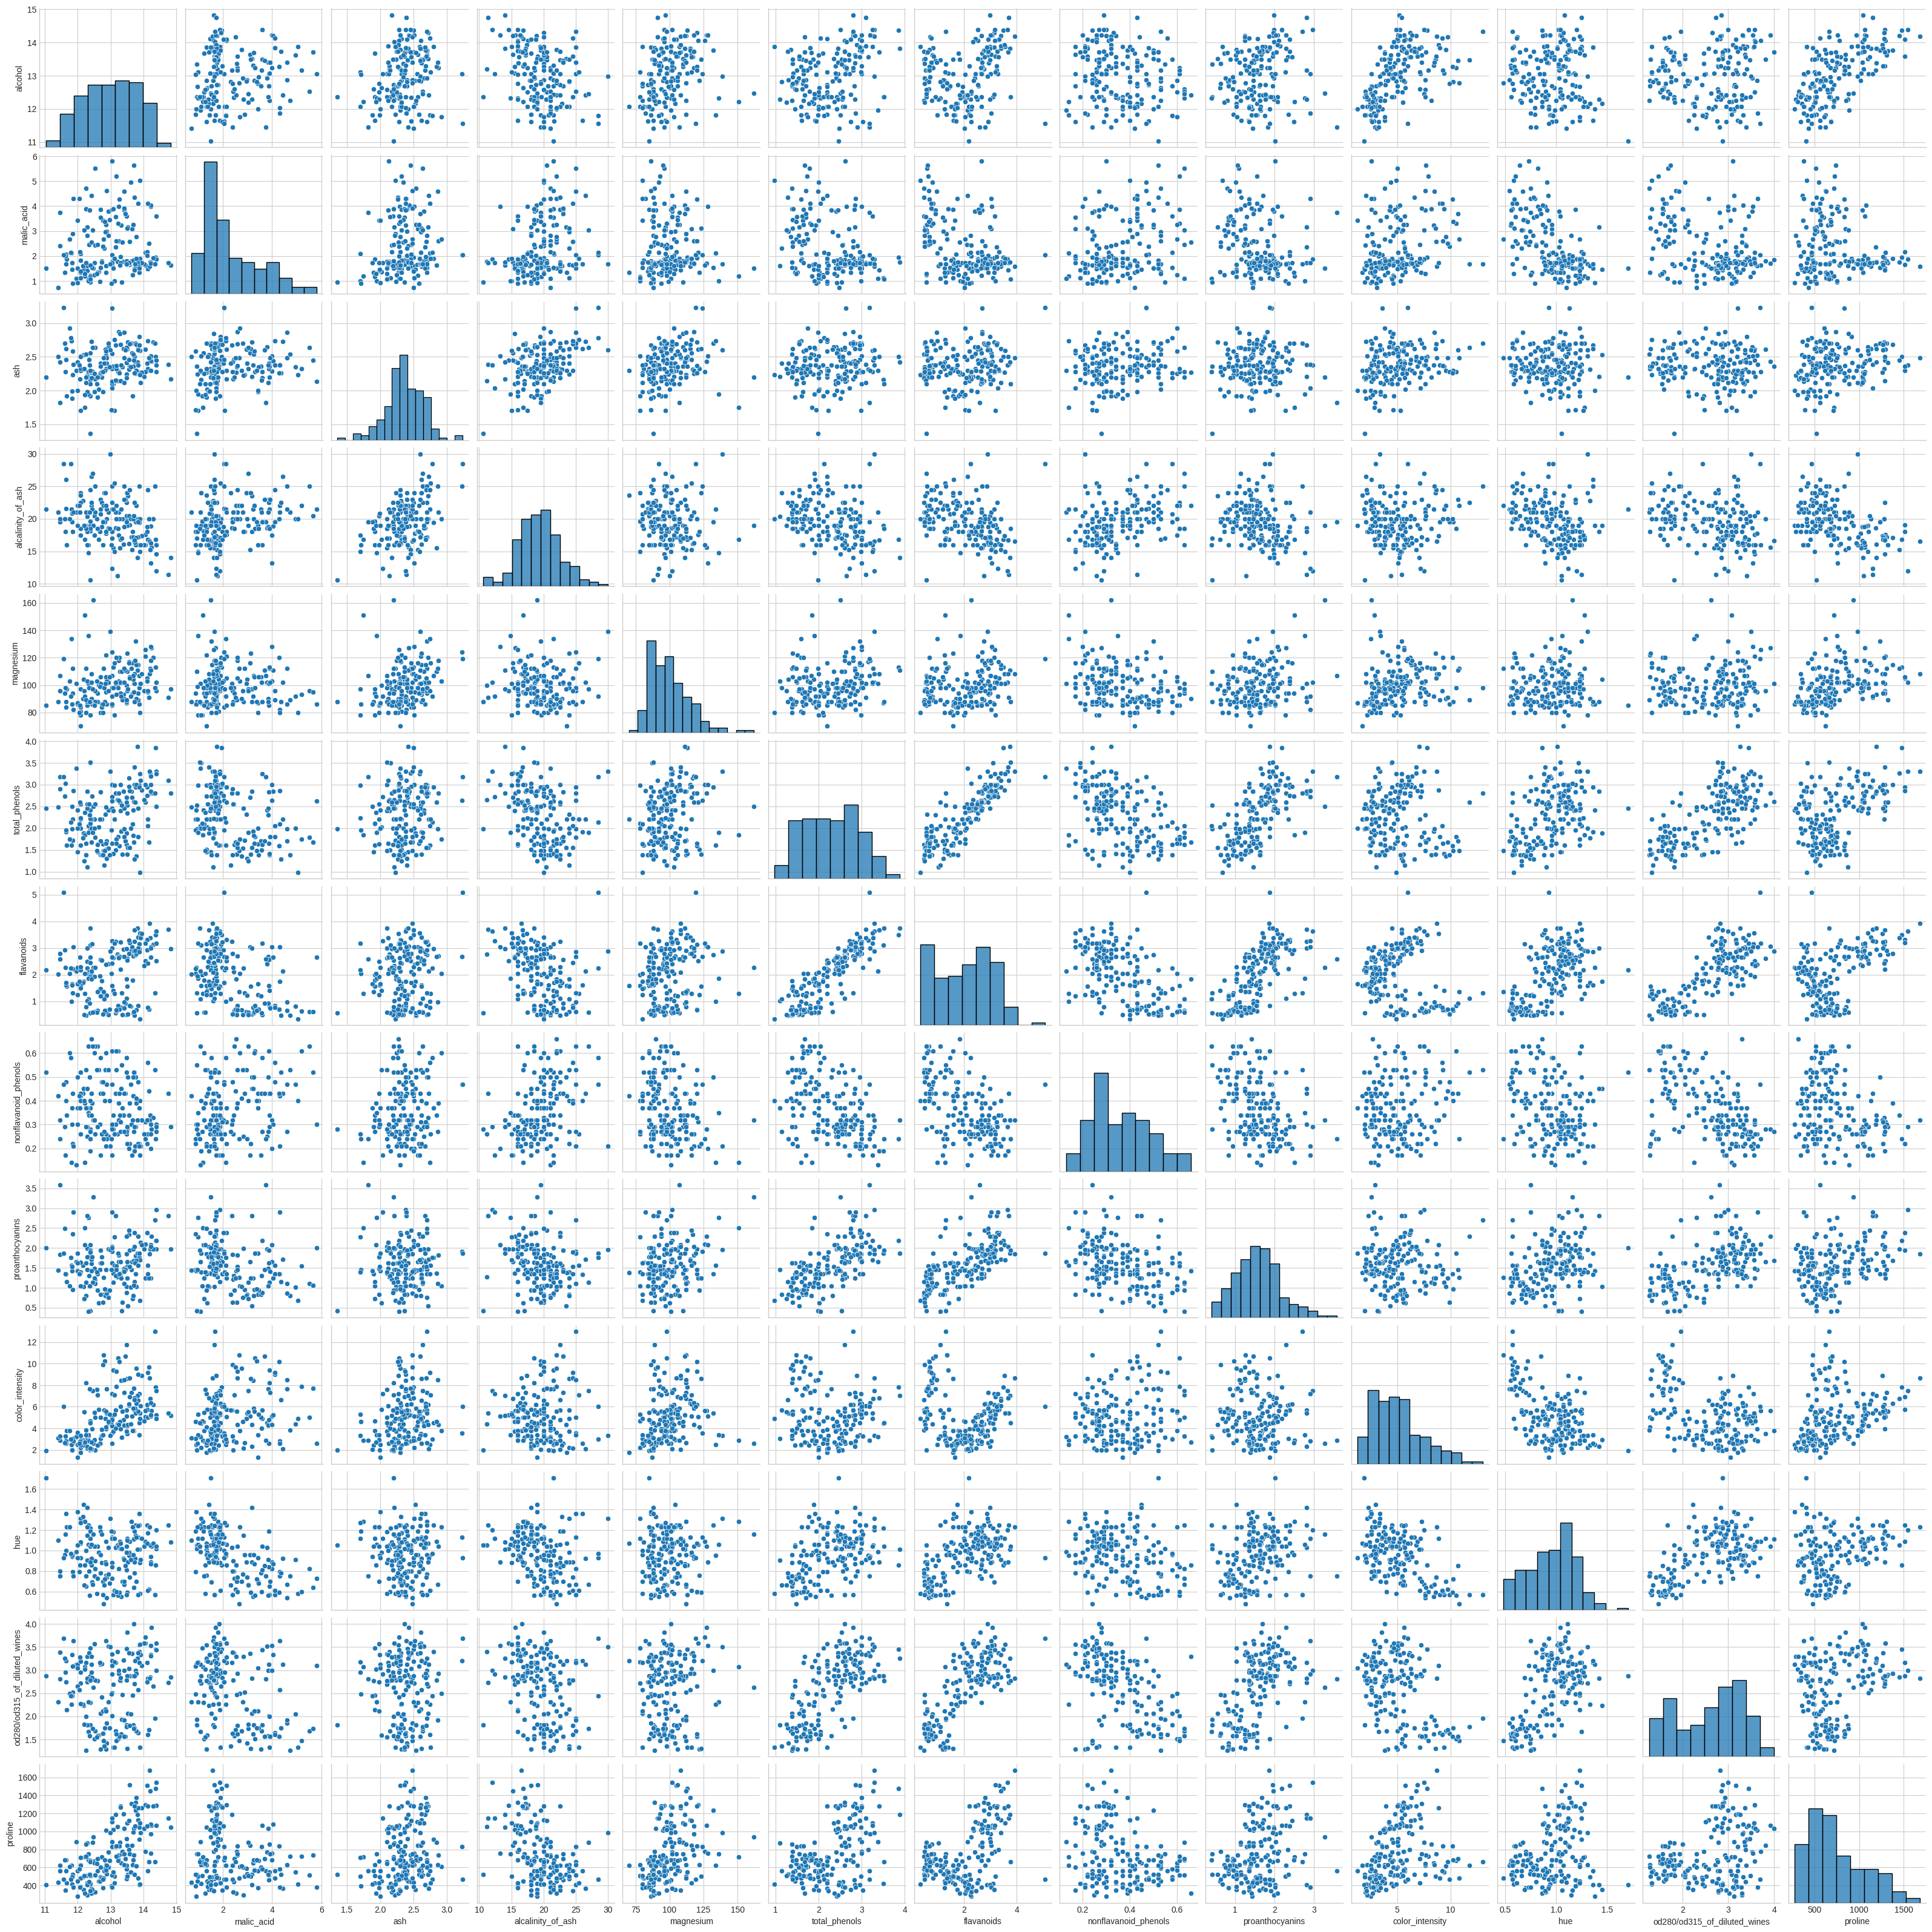

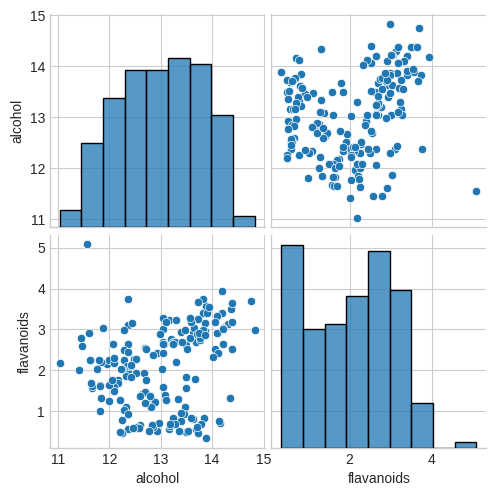

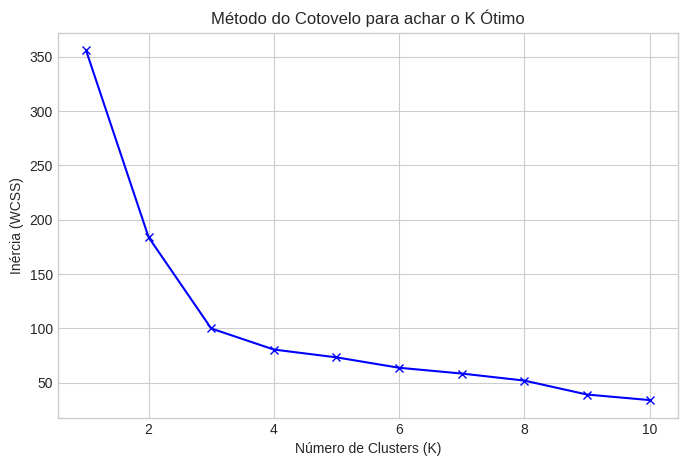

In [35]:
wine = load_wine()
X_wine = wine.data
y_wine = wine.target

print("Dataset Wine:")
print(f"Shape: {X_wine.shape}")
print(f"Features: {wine.feature_names}")
print(f"Classes: {wine.target_names}")

# 2. Análise das features para seleção
# Seu código aqui

print(wine.DESCR)

df = pd.DataFrame(wine.data, columns=wine.feature_names)
sns.pairplot(df)
df.head()


# 3. Seleção das duas melhores features
# Seu código aqui


df_norm = scale.fit_transform(df[["alcohol","flavanoids"]])
df_norm = pd.DataFrame(data=df_norm, columns=[["alcohol", "flavanoids"]])
sns.pairplot(df[["alcohol", "flavanoids"]])

from sklearn.cluster import KMeans
inercia = []

K_range = range(1, 11)

for k in K_range:
    model = KMeans(n_init="auto", n_clusters=k, random_state=42)
    model.fit(df_norm)
    inercia.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inercia, 'bx-')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia (WCSS)')
plt.title('Método do Cotovelo para achar o K Ótimo')
plt.show()



single
Passo inicial: 178 clusters individuais
Clusters: [[0], [1], [2], [3], [4], [5], [6], [7], [8], [9], [10], [11], [12], [13], [14], [15], [16], [17], [18], [19], [20], [21], [22], [23], [24], [25], [26], [27], [28], [29], [30], [31], [32], [33], [34], [35], [36], [37], [38], [39], [40], [41], [42], [43], [44], [45], [46], [47], [48], [49], [50], [51], [52], [53], [54], [55], [56], [57], [58], [59], [60], [61], [62], [63], [64], [65], [66], [67], [68], [69], [70], [71], [72], [73], [74], [75], [76], [77], [78], [79], [80], [81], [82], [83], [84], [85], [86], [87], [88], [89], [90], [91], [92], [93], [94], [95], [96], [97], [98], [99], [100], [101], [102], [103], [104], [105], [106], [107], [108], [109], [110], [111], [112], [113], [114], [115], [116], [117], [118], [119], [120], [121], [122], [123], [124], [125], [126], [127], [128], [129], [130], [131], [132], [133], [134], [135], [136], [137], [138], [139], [140], [141], [142], [143], [144], [145], [146], [147], [148], [149], [1

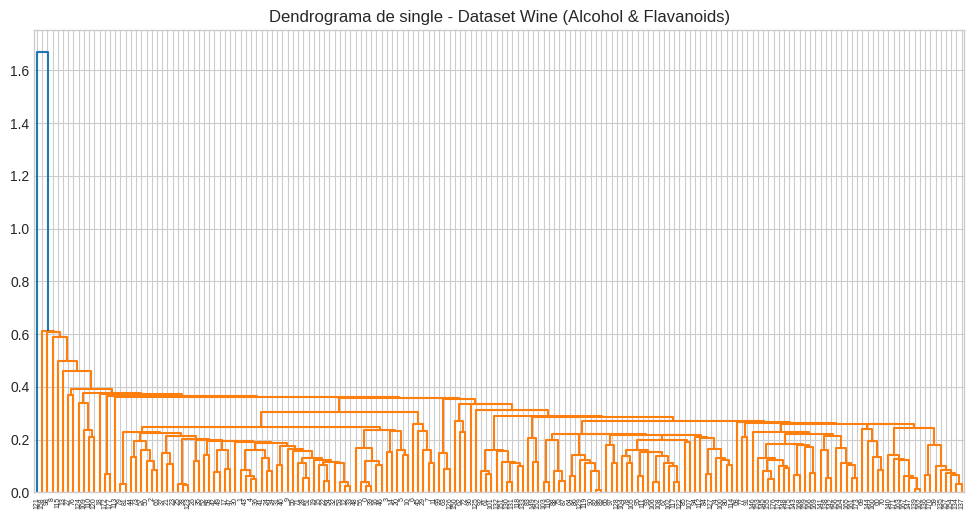

In [36]:
# 4. Aplicação dos métodos de ligação e criação dos dendrogramas
# Seu código aqui
print("single")
hc_s=HierarchicalClustering(linkage="single")
hc_s.fit(df_norm.values)

linkage_matrix_wine = linkage(df_norm.values, method='single')
plt.figure(figsize=(12, 6))
# Usando os nomes das classes ou índices dos vinhos
dendrogram(linkage_matrix_wine)

# Encontre o maior salto vertical e passe a linha de corte ali
# Para 3 clusters (vinhos), geralmente o corte é feito na metade 
# do caminho entre a penúltima e a última união.
plt.axhline(y=10, color='r', linestyle='--', label='Corte Sugerido para 3 Grupos') 

plt.title('Dendrograma de single - Dataset Wine (Alcohol & Flavanoids)')
plt.show()

compile
Passo inicial: 178 clusters individuais
Clusters: [[0], [1], [2], [3], [4], [5], [6], [7], [8], [9], [10], [11], [12], [13], [14], [15], [16], [17], [18], [19], [20], [21], [22], [23], [24], [25], [26], [27], [28], [29], [30], [31], [32], [33], [34], [35], [36], [37], [38], [39], [40], [41], [42], [43], [44], [45], [46], [47], [48], [49], [50], [51], [52], [53], [54], [55], [56], [57], [58], [59], [60], [61], [62], [63], [64], [65], [66], [67], [68], [69], [70], [71], [72], [73], [74], [75], [76], [77], [78], [79], [80], [81], [82], [83], [84], [85], [86], [87], [88], [89], [90], [91], [92], [93], [94], [95], [96], [97], [98], [99], [100], [101], [102], [103], [104], [105], [106], [107], [108], [109], [110], [111], [112], [113], [114], [115], [116], [117], [118], [119], [120], [121], [122], [123], [124], [125], [126], [127], [128], [129], [130], [131], [132], [133], [134], [135], [136], [137], [138], [139], [140], [141], [142], [143], [144], [145], [146], [147], [148], [149], [

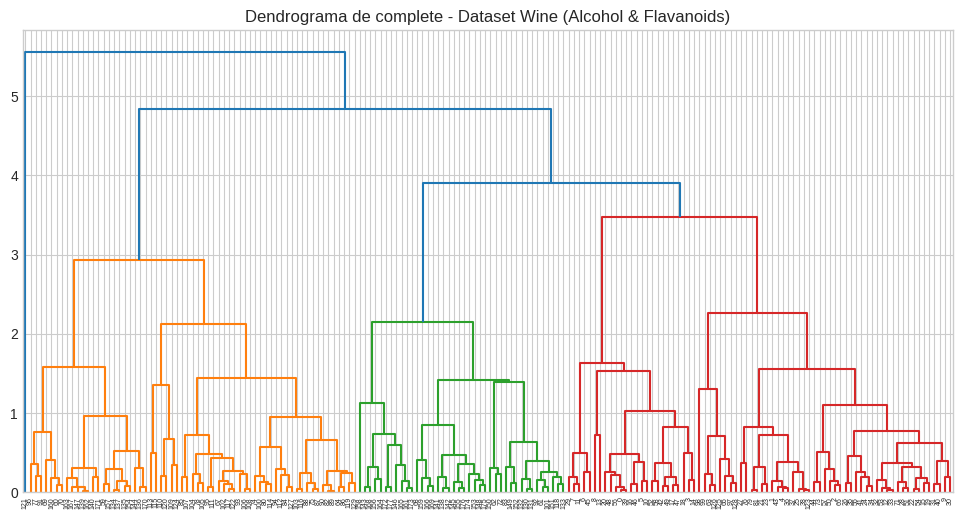

In [37]:
print("compile")
hc_c = HierarchicalClustering(linkage="complete")
hc_c.fit(df_norm.values)

linkage_matrix_wine = linkage(df_norm.values, method='complete')

plt.figure(figsize=(12, 6))
# Usando os nomes das classes ou índices dos vinhos
dendrogram(linkage_matrix_wine)

# Encontre o maior salto vertical e passe a linha de corte ali
# Para 3 clusters (vinhos), geralmente o corte é feito na metade 
# do caminho entre a penúltima e a última união.
plt.axhline(y=10, color='r', linestyle='--', label='Corte Sugerido para 3 Grupos') 

plt.title('Dendrograma de complete - Dataset Wine (Alcohol & Flavanoids)')
plt.show()

ward
Passo inicial: 178 clusters individuais
Clusters: [[0], [1], [2], [3], [4], [5], [6], [7], [8], [9], [10], [11], [12], [13], [14], [15], [16], [17], [18], [19], [20], [21], [22], [23], [24], [25], [26], [27], [28], [29], [30], [31], [32], [33], [34], [35], [36], [37], [38], [39], [40], [41], [42], [43], [44], [45], [46], [47], [48], [49], [50], [51], [52], [53], [54], [55], [56], [57], [58], [59], [60], [61], [62], [63], [64], [65], [66], [67], [68], [69], [70], [71], [72], [73], [74], [75], [76], [77], [78], [79], [80], [81], [82], [83], [84], [85], [86], [87], [88], [89], [90], [91], [92], [93], [94], [95], [96], [97], [98], [99], [100], [101], [102], [103], [104], [105], [106], [107], [108], [109], [110], [111], [112], [113], [114], [115], [116], [117], [118], [119], [120], [121], [122], [123], [124], [125], [126], [127], [128], [129], [130], [131], [132], [133], [134], [135], [136], [137], [138], [139], [140], [141], [142], [143], [144], [145], [146], [147], [148], [149], [150

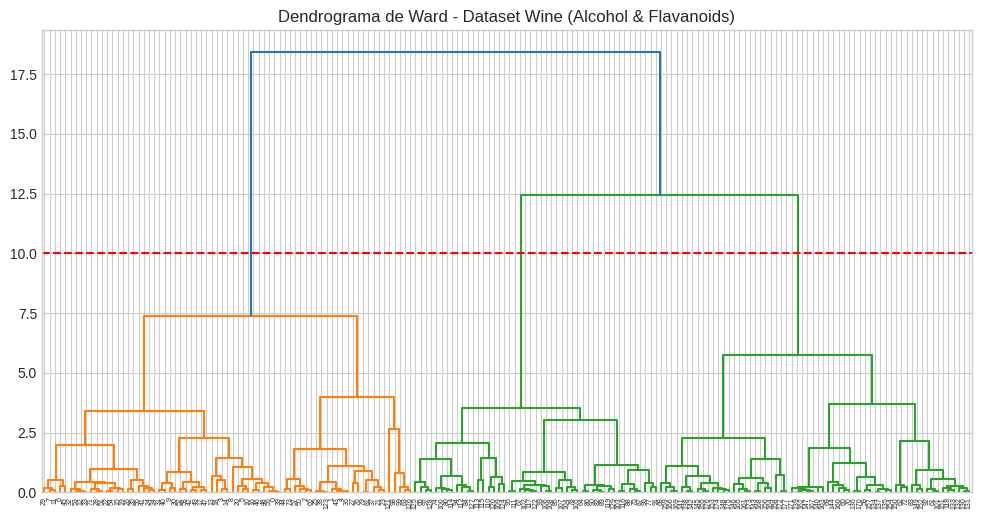

In [38]:

print("ward")

hc_w = HierarchicalClustering(linkage="ward")
hc_w.fit(df_norm.values)

linkage_matrix_wine = linkage(df_norm.values, method='ward')

# Definir diferentes alturas de corte
plt.figure(figsize=(12, 6))
# Usando os nomes das classes ou índices dos vinhos
dendrogram(linkage_matrix_wine)

# Encontre o maior salto vertical e passe a linha de corte ali
# Para 3 clusters (vinhos), geralmente o corte é feito na metade 
# do caminho entre a penúltima e a última união.
plt.axhline(y=10, color='r', linestyle='--', label='Corte Sugerido para 3 Grupos') 

plt.title('Dendrograma de Ward - Dataset Wine (Alcohol & Flavanoids)')
plt.show()

Passo inicial: 178 clusters individuais
Clusters: [[0], [1], [2], [3], [4], [5], [6], [7], [8], [9], [10], [11], [12], [13], [14], [15], [16], [17], [18], [19], [20], [21], [22], [23], [24], [25], [26], [27], [28], [29], [30], [31], [32], [33], [34], [35], [36], [37], [38], [39], [40], [41], [42], [43], [44], [45], [46], [47], [48], [49], [50], [51], [52], [53], [54], [55], [56], [57], [58], [59], [60], [61], [62], [63], [64], [65], [66], [67], [68], [69], [70], [71], [72], [73], [74], [75], [76], [77], [78], [79], [80], [81], [82], [83], [84], [85], [86], [87], [88], [89], [90], [91], [92], [93], [94], [95], [96], [97], [98], [99], [100], [101], [102], [103], [104], [105], [106], [107], [108], [109], [110], [111], [112], [113], [114], [115], [116], [117], [118], [119], [120], [121], [122], [123], [124], [125], [126], [127], [128], [129], [130], [131], [132], [133], [134], [135], [136], [137], [138], [139], [140], [141], [142], [143], [144], [145], [146], [147], [148], [149], [150], [1

TypeError: '<' not supported between instances of 'NoneType' and 'float'

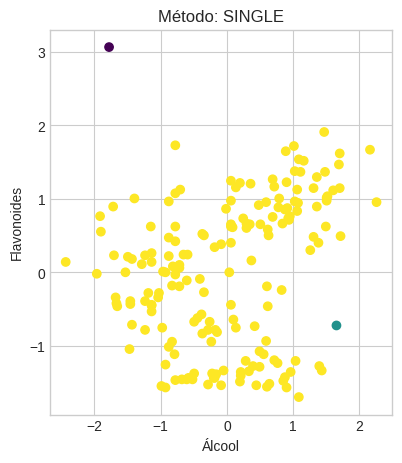

In [41]:
# 4. Aplicação dos métodos e Visualização

import matplotlib.pyplot as plt

metodos = ['single', 'average', 'ward']
plt.figure(figsize=(15, 5))

for i, link in enumerate(metodos):
    # Instancia o SEU algoritmo
    modelo = HierarchicalClustering(linkage=link)
    # Rodando nos dados normalizados do Wine (apenas 2 colunas)
    modelo.fit(df_norm.values)
    
    # Lógica para extrair labels (0, 1, 2) dos clusters finais
    labels = np.zeros(len(df_norm))
    for cluster_idx, indices in enumerate(modelo.clusters):
        for idx in indices:
            labels[idx] = cluster_idx
            
    # Plotagem
    plt.subplot(1, 3, i+1)
    plt.scatter(df_norm["alcohol"], df_norm["flavanoids"], c=labels, cmap='viridis')
    plt.title(f'Método: {link.upper()}')
    plt.xlabel('Álcool')
    plt.ylabel('Flavonoides')

plt.tight_layout()
plt.show()

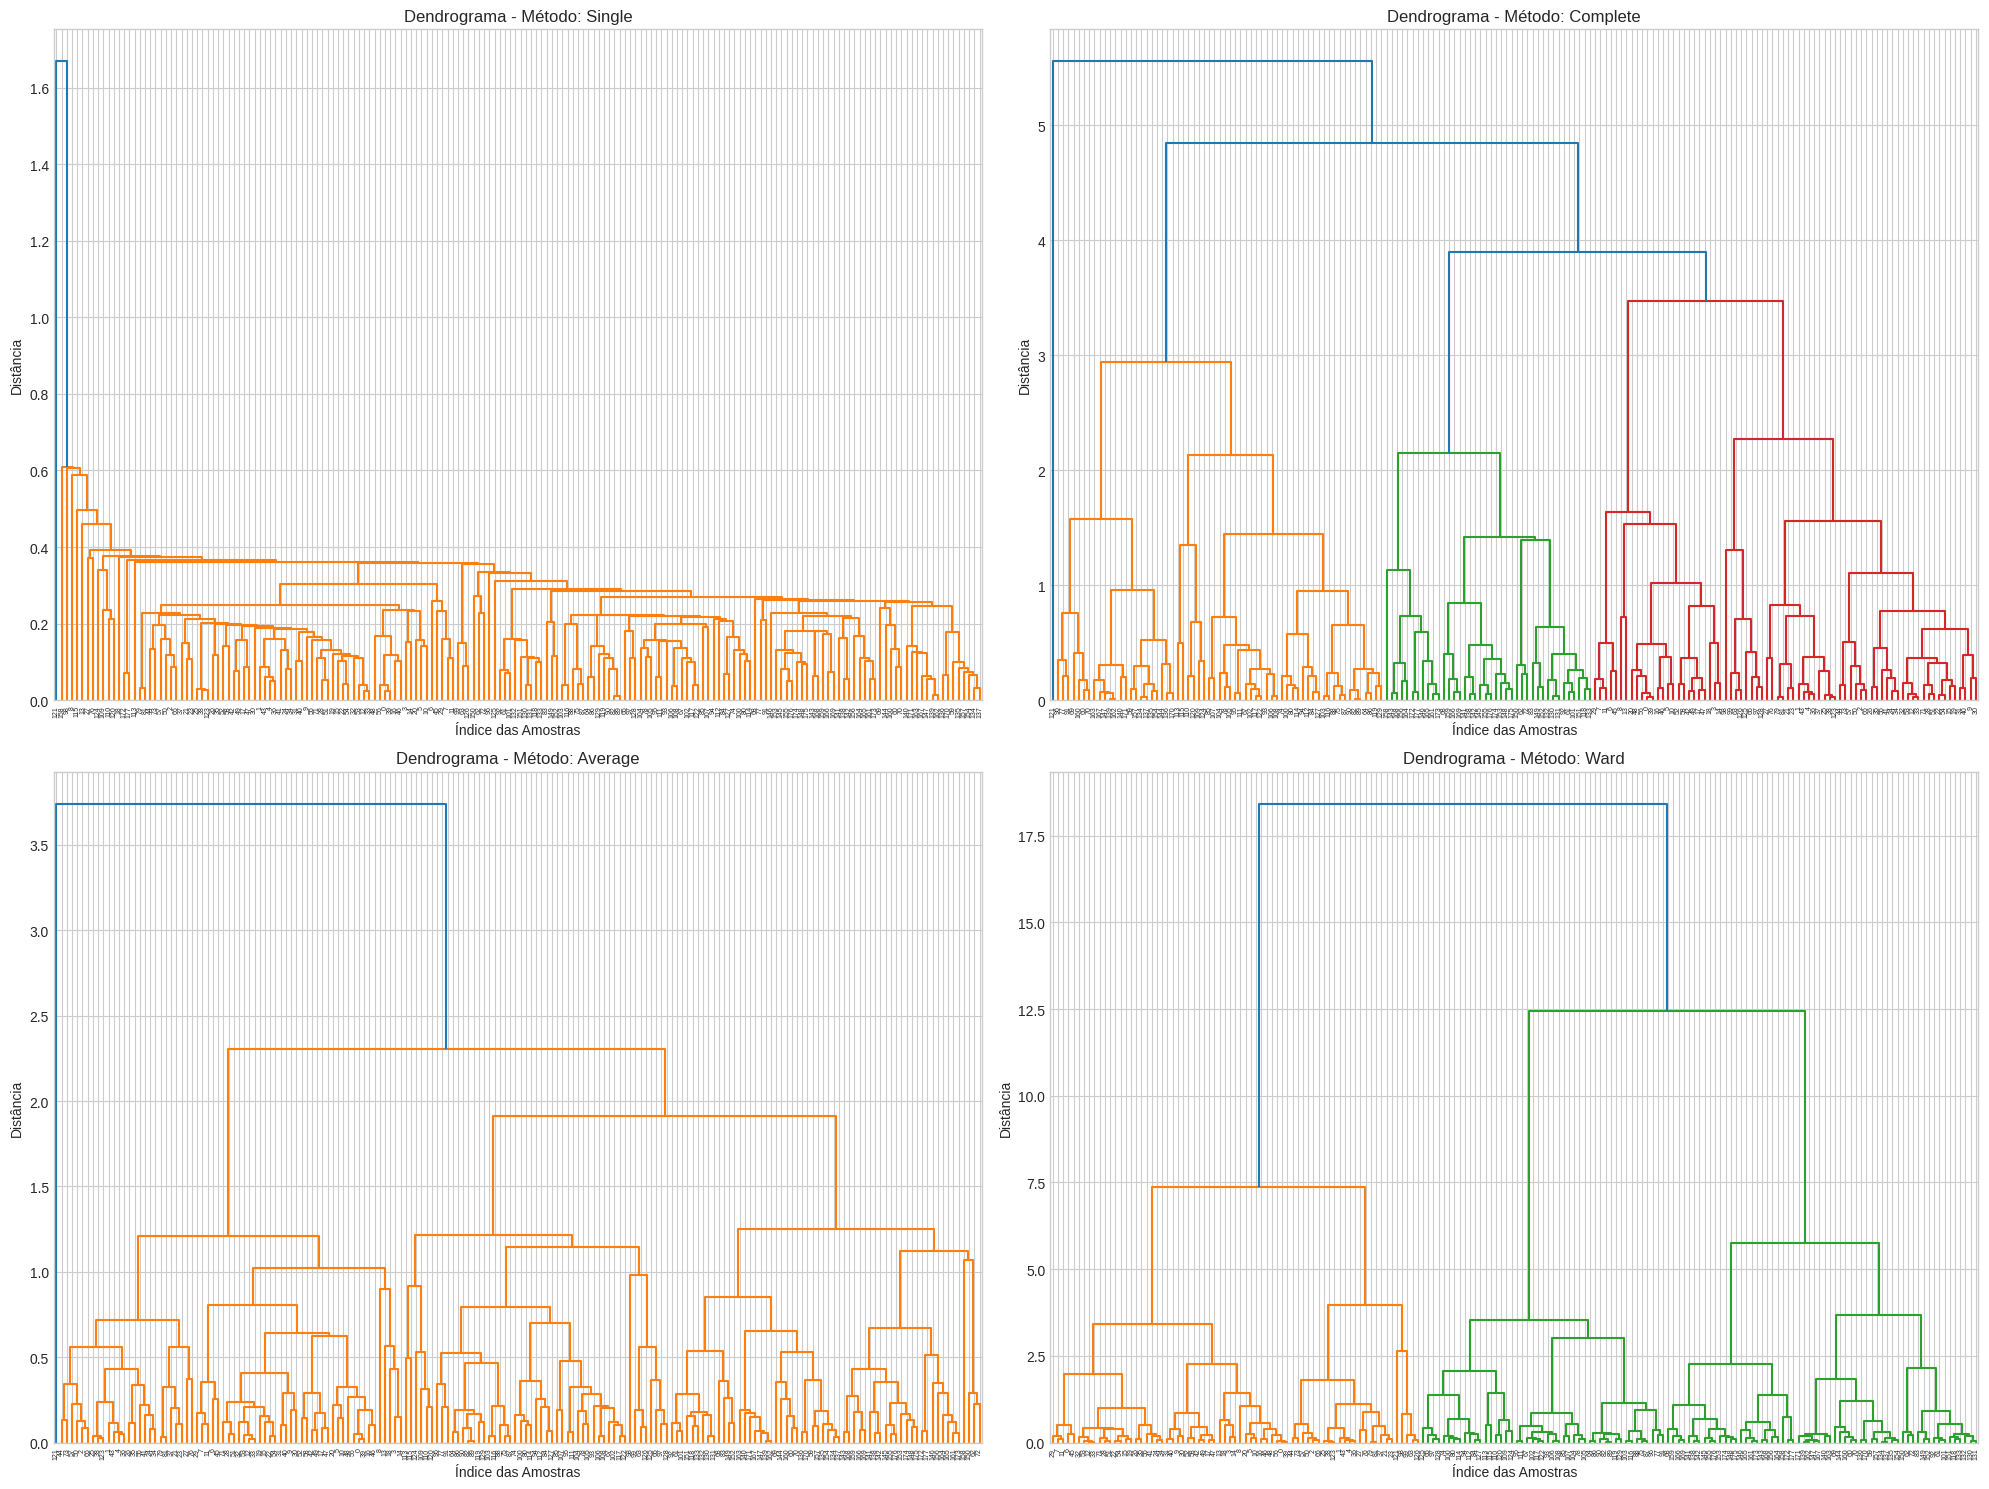

In [40]:
# 5. Análise visual e determinação do melhor método
# Seu código aqui
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Lista de métodos para testar
metodos = ['single', 'complete', 'average', 'ward']

plt.figure(figsize=(20, 15))

for i, metodo in enumerate(metodos):
    plt.subplot(2, 2, i+1)
    # Gera a matriz de ligação
    Z = linkage(df_norm, method=metodo) 
    
    # Plota o dendrograma
    dendrogram(Z)
    plt.title(f'Dendrograma - Método: {metodo.capitalize()}')
    plt.xlabel('Índice das Amostras')
    plt.ylabel('Distância')

plt.tight_layout()
plt.show()


### Exercício 3: Determinação do Número Ótimo de Clusters

Com base no melhor método de ligação identificado no Exercício 2, determine o número ótimo de clusters para o dataset Wine usando análise visual do dendrograma e validação com os rótulos verdadeiros.

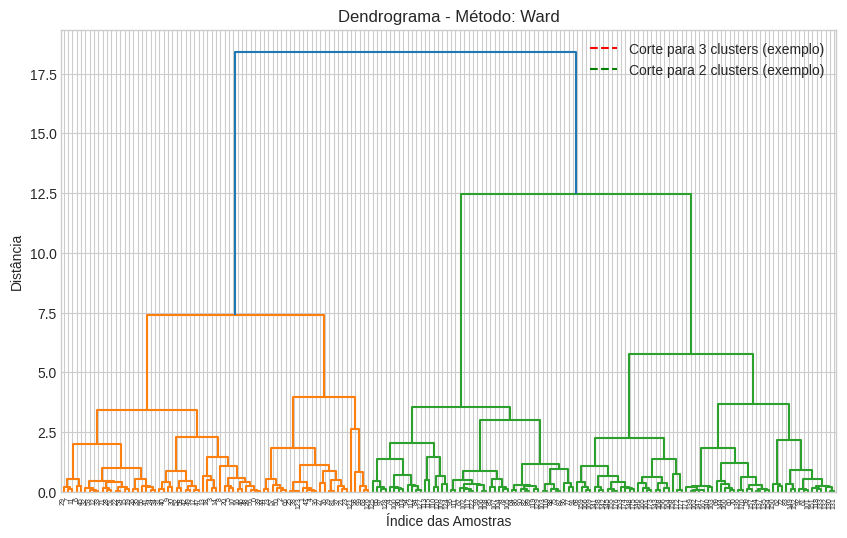

Análise do número ótimo de clusters:
Clusters: 2
- Silhouette Score: 0.4473
- Adjusted Rand Index (vs Realidade): 0.4668
--------------------
Clusters: 3
- Silhouette Score: 0.4739
- Adjusted Rand Index (vs Realidade): 0.6376
--------------------
Clusters: 4
- Silhouette Score: 0.4320
- Adjusted Rand Index (vs Realidade): 0.5976
--------------------
Clusters: 5
- Silhouette Score: 0.4079
- Adjusted Rand Index (vs Realidade): 0.5331
--------------------


In [ ]:
# Exercício 3: Determinação do Número Ótimo de Clusters
from sklearn.metrics import silhouette_score, adjusted_rand_score
# 1. Use o melhor método do exercício anterior
# best_method = '...'
best_method= "ward"
Z = linkage(df_norm, best_method)


# 2. Crie dendrograma com diferentes linhas de corte
# Seu código aqui
plt.figure(figsize=(10, 6))

dendrogram(Z)
plt.title(f'Dendrograma - Método: {metodo.capitalize()}')
plt.xlabel('Índice das Amostras')
plt.ylabel('Distância')
plt.legend()
plt.show()

# 3. Teste diferentes números de clusters
n_clusters_to_test = [2, 3, 4, 5]

print("Análise do número ótimo de clusters:")
print("=" * 40)

for n in n_clusters_to_test:
    # fcluster extrai os grupos. 'maxclust' força o algoritmo a encontrar n clusters.
    clusters = fcluster(Z, n, criterion='maxclust')
    
    # Validação (usando os rótulos reais 'y' do dataset Wine)
    # Adjusted Rand Score mede a similaridade entre dois agrupamentos (1.0 é perfeito)
    ari = adjusted_rand_score(y_wine, clusters)
    
    # Coeficiente de Silhueta (mede quão bem os pontos estão agrupados neles mesmos)
    sil = silhouette_score(df_norm, clusters)
    
    print(f"Clusters: {n}")
    print(f"- Silhouette Score: {sil:.4f}")
    print(f"- Adjusted Rand Index (vs Realidade): {ari:.4f}")
    print("-" * 20)

# Seu código aqui